In [5]:
import os
import shutil
from pathlib import Path
import pandas as pd
import shutil
import random

import sys
from PIL import Image
import torch
import torchvision
import timm
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import cohen_kappa_score
from collections import Counter
import torch.nn.functional as F
import torch.optim as optim

import torch.nn as nn


print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/myenv/bin/python


In [6]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
GPU: NVIDIA RTX A4000


In [11]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16 # CHANGED FROM 32
NUM_CLASSES = 5
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DATA_DIR = Path("/kaggle/working/SplitDATA") / "data"
DATA_DIR = Path("SplitDATA") / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_NAME = "deit_small_distilled_patch16_224"
MODEL_NAME_BASELINE = "deit_small_patch16_224"

TEACHER_NAME = "regnety_160"

NUM_EPOCHS = 12
TEACHER_EPOCHS = 12
LEARNING_RATE = 5e-5 #1e-4
ALPHA = 0.2
#ALPHA = 0.3
TAU = 2.0
# LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
# ALPHA = 0.5
# TAU = 1.0
PATIENCE = 8 #5


In [ ]:
class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(NUM_CLASSES):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = DRDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DRDataset(VAL_DIR, transform=val_test_transform)
test_dataset = DRDataset(TEST_DIR, transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")


class_counts = Counter(train_dataset.labels)
print("Class counts:", class_counts)


class_weights = None

print("Class weights disabled to prevent severe-class overprediction.")


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nData loaders ready!")

Train dataset: 21074 images
Val dataset:   7026 images
Test dataset:  7026 images
Class counts: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Class weights disabled to prevent severe-class overprediction.

Data loaders ready!


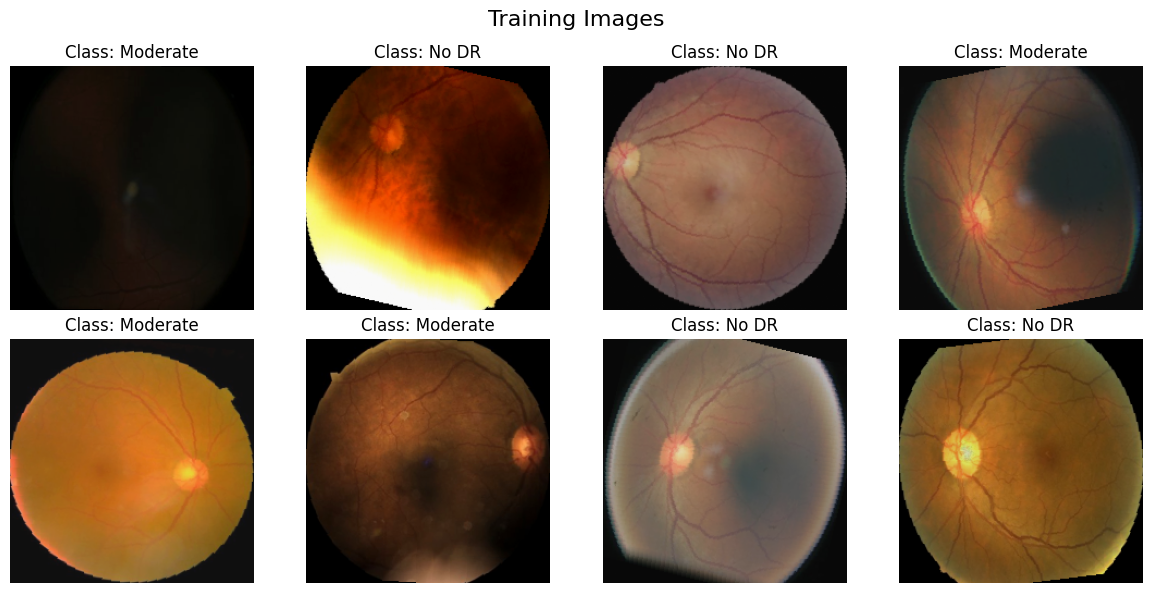

In [13]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [14]:
# creating FULL DeiT student model
student_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f"Student model: {MODEL_NAME}")
print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")

Student model: deit_small_distilled_patch16_224
Total params: 21.67M
Trainable params: 21.67M


In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, cohen_kappa_score

os.makedirs("SplitDATA/checkpoints", exist_ok=True)
os.makedirs("SplitDATA/logs", exist_ok=True)

teacher_ckpt = "SplitDATA/checkpoints/teacher_regnety160_best.pth"
teacher_log_path = "SplitDATA/logs/teacher_training_log.txt"

teacher_model = timm.create_model(
    TEACHER_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

def train_teacher_if_needed(model, train_loader, val_loader, ckpt_path, epochs=TEACHER_EPOCHS):

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print("Loaded existing teacher checkpoint")
        return model

    criterion_teacher = nn.CrossEntropyLoss(
        #weight=class_weights,
        label_smoothing=0.05
    )

    optimizer_teacher = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_teacher = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_teacher,
        T_max=epochs,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val_qwk = -1.0
    best_val_f1 = -1.0

    with open(teacher_log_path, "w") as f:
        f.write("====================================================\n")
        f.write("Teacher Training Log - RegNetY-160\n")
        f.write("====================================================\n\n")

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        train_preds, train_labels = [], []

        for images, labels in tqdm(train_loader, desc=f"Teacher Train {epoch+1}/{epochs}", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_teacher.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer_teacher)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer_teacher)
            scaler.update()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_preds.extend(preds.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average="macro")

        model.eval()

        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():

            for images, labels in tqdm(val_loader, desc=f"Teacher Val {epoch+1}/{epochs}", leave=False):

                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)

        val_acc = accuracy_score(val_labels, val_preds)
        val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro")
        val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

        scheduler_teacher.step()

        epoch_log = (
            f"\n====================================================\n"
            f"Teacher Epoch {epoch+1}/{epochs}\n"
            f"====================================================\n"
            f"Train Loss          : {train_loss:.4f}\n"
            f"Train Accuracy      : {train_acc*100:.2f}%\n"
            f"Train Macro-F1      : {train_f1:.4f}\n\n"
            f"Val Loss            : {val_loss:.4f}\n"
            f"Val Accuracy        : {val_acc*100:.2f}%\n"
            f"Val Balanced Acc    : {val_bal_acc:.4f}\n"
            f"Val Macro-F1        : {val_f1:.4f}\n"
            f"Val QWK             : {val_qwk:.4f}\n"
        )

        print(epoch_log)

        with open(teacher_log_path, "a") as f:
            f.write(epoch_log)

     
        if val_qwk > best_val_qwk:

            best_val_qwk = val_qwk
            best_val_f1 = val_f1

            torch.save(model.state_dict(), ckpt_path)

            msg = (
                f"\nBest teacher saved\n"
                f"Best Val QWK      : {best_val_qwk:.4f}\n"
                f"Val Macro-F1      : {best_val_f1:.4f}\n"
            )

            print(msg)

            with open(teacher_log_path, "a") as f:
                f.write(msg)

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    final_msg = (
        f"\nTeacher ready\n"
        f"Best Val QWK      : {best_val_qwk:.4f}\n"
        f"Best Val Macro-F1 : {best_val_f1:.4f}\n"
    )

    print(final_msg)

    with open(teacher_log_path, "a") as f:
        f.write(final_msg)

    return model

teacher_model = train_teacher_if_needed(
    teacher_model,
    train_loader,
    val_loader,
    teacher_ckpt,
    epochs=TEACHER_EPOCHS
)

teacher_model.eval()

for p in teacher_model.parameters():
    p.requires_grad = False

print("Teacher loaded and frozen for distillation.")


Teacher Epoch 1/12
Train Loss          : 0.9722
Train Accuracy      : 73.10%
Train Macro-F1      : 0.1720

Val Loss            : 0.9709
Val Accuracy        : 73.51%
Val Balanced Acc    : 0.2000
Val Macro-F1        : 0.1695
Val QWK             : 0.0000


Best teacher saved
Best Val QWK      : 0.0000
Val Macro-F1      : 0.1695




Teacher Epoch 2/12
Train Loss          : 0.9479
Train Accuracy      : 73.51%
Train Macro-F1      : 0.1695

Val Loss            : 0.9503
Val Accuracy        : 73.51%
Val Balanced Acc    : 0.2000
Val Macro-F1        : 0.1695
Val QWK             : 0.0000




Teacher Epoch 3/12
Train Loss          : 0.9415
Train Accuracy      : 73.51%
Train Macro-F1      : 0.1695

Val Loss            : 0.9613
Val Accuracy        : 73.51%
Val Balanced Acc    : 0.2000
Val Macro-F1        : 0.1695
Val QWK             : 0.0000




Teacher Epoch 4/12
Train Loss          : 0.9387
Train Accuracy      : 73.51%
Train Macro-F1      : 0.1695

Val Loss            : 0.9725
Val Accuracy        : 73.51%
Val Balanced Acc    : 0.2000
Val Macro-F1        : 0.1695
Val QWK             : 0.0000




Teacher Epoch 5/12
Train Loss          : 0.9322
Train Accuracy      : 73.50%
Train Macro-F1      : 0.1695

Val Loss            : 0.9308
Val Accuracy        : 73.44%
Val Balanced Acc    : 0.2034
Val Macro-F1        : 0.1783
Val QWK             : 0.0657


Best teacher saved
Best Val QWK      : 0.0657
Val Macro-F1      : 0.1783



...


Teacher Epoch 10/12
Train Loss          : 0.8362
Train Accuracy      : 75.48%
Train Macro-F1      : 0.2747

Val Loss            : 0.8545
Val Accuracy        : 75.56%
Val Balanced Acc    : 0.2541
Val Macro-F1        : 0.2615
Val QWK             : 0.3128




Teacher Epoch 11/12
Train Loss          : 0.8244
Train Accuracy      : 75.89%
Train Macro-F1      : 0.2929

Val Loss            : 0.8427
Val Accuracy        : 75.73%
Val Balanced Acc    : 0.2664
Val Macro-F1        : 0.2778
Val QWK             : 0.3624


Best teacher saved
Best Val QWK      : 0.3624
Val Macro-F1      : 0.2778




Teacher Epoch 12/12
Train Loss          : 0.8165
Train Accuracy      : 76.20%
Train Macro-F1      : 0.3064

Val Loss            : 0.8399
Val Accuracy        : 75.90%
Val Balanced Acc    : 0.2870
Val Macro-F1        : 0.3073
Val QWK             : 0.3831


Best teacher saved
Best Val QWK      : 0.3831
Val Macro-F1      : 0.3073



/tmp/ipykernel_617293/681341331.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))



Teacher ready
Best Val QWK      : 0.3831
Best Val Macro-F1 : 0.3073

Teacher loaded and frozen for distillation.


In [16]:

import torch.optim as optim
# Distillation training setup
criterion_cls = nn.CrossEntropyLoss(
    #weight=class_weights,
    label_smoothing=0.05
)

# KL divergence for soft distillation
criterion_dist = nn.KLDivLoss(reduction="batchmean")

optimizer = optim.AdamW(
    student_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f"ALPHA = {ALPHA}, TAU = {TAU}")

ALPHA = 0.2, TAU = 2.0


In [ ]:

# DeiT WITHOUT DISTILLATION token / Uses normal DeiT, no teacher

baseline_model = timm.create_model(
    MODEL_NAME_BASELINE,
    pretrained=True,
    num_classes=5
).to(DEVICE)

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=NUM_EPOCHS
)

baseline_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

best_baseline_qwk = -1.0
baseline_patience_counter = 0

baseline_log_path = "SplitDATA/logs/deit_without_distillation_log.txt"

with open(baseline_log_path, "w") as f:
    f.write("=====================================================\n")
    f.write("DeiT WITHOUT Distillation Training Log\n")
    f.write("=====================================================\n\n")
    f.write(f"Model: {MODEL_NAME_BASELINE}\n")
    f.write("Teacher Used: No\n")
    f.write("Loss: CrossEntropy only\n\n")

for epoch in range(1, NUM_EPOCHS + 1):

    baseline_model.train()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"No-Distill Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

        baseline_scaler.scale(loss).backward()

        baseline_scaler.unscale_(baseline_optimizer)
        torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), max_norm=1.0)

        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()
        # baseline_scaler.step(baseline_optimizer)
        # baseline_scaler.update()

        train_loss += loss.item()

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")


    baseline_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"No-Distill Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

    baseline_scheduler.step()

    epoch_log = (
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"Train Loss          : {train_loss:.4f}\n"
        f"Train Accuracy      : {train_acc*100:.2f}%\n"
        f"Train Macro-F1      : {train_f1:.4f}\n"
        f"Validation Loss     : {val_loss:.4f}\n"
        f"Validation Accuracy : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc  : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1 : {val_f1:.4f}\n"
        f"Validation QWK      : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(baseline_log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_baseline_qwk:

        best_baseline_qwk = val_qwk
        baseline_patience_counter = 0

        torch.save(
            baseline_model.state_dict(),
            "SplitDATA/checkpoints/best_deit_without_distillation.pth"
        )

        msg = f"\nBest no-distillation DeiT saved | Val QWK: {val_qwk:.4f}\n"
        print(msg)

        with open(baseline_log_path, "a") as f:
            f.write(msg)

    else:

        baseline_patience_counter += 1

        if baseline_patience_counter >= PATIENCE:
            stop_msg = f"\nEarly stopping at epoch {epoch}\n"
            print(stop_msg)

            with open(baseline_log_path, "a") as f:
                f.write(stop_msg)

            break

print(f"DeiT without distillation complete | Best Val QWK: {best_baseline_qwk:.4f}")


Epoch 01/12
Train Loss          : 0.8563
Train Accuracy      : 75.11%
Train Macro-F1      : 0.3084
Validation Loss     : 0.8459
Validation Accuracy : 76.57%
Validation Bal Acc  : 0.3052
Validation Macro-F1 : 0.3431
Validation QWK      : 0.3844


Best no-distillation DeiT saved | Val QWK: 0.3844




Epoch 02/12
Train Loss          : 0.7991
Train Accuracy      : 77.11%
Train Macro-F1      : 0.4009
Validation Loss     : 0.7996
Validation Accuracy : 77.54%
Validation Bal Acc  : 0.3748
Validation Macro-F1 : 0.4186
Validation QWK      : 0.5165


Best no-distillation DeiT saved | Val QWK: 0.5165




Epoch 03/12
Train Loss          : 0.7720
Train Accuracy      : 78.05%
Train Macro-F1      : 0.4345
Validation Loss     : 0.7913
Validation Accuracy : 77.60%
Validation Bal Acc  : 0.3852
Validation Macro-F1 : 0.4271
Validation QWK      : 0.5300


Best no-distillation DeiT saved | Val QWK: 0.5300




Epoch 04/12
Train Loss          : 0.7472
Train Accuracy      : 79.12%
Train Macro-F1      : 0.4615
Validation Loss     : 0.7813
Validation Accuracy : 78.29%
Validation Bal Acc  : 0.3925
Validation Macro-F1 : 0.4367
Validation QWK      : 0.5576


Best no-distillation DeiT saved | Val QWK: 0.5576




Epoch 05/12
Train Loss          : 0.7160
Train Accuracy      : 80.34%
Train Macro-F1      : 0.5017
Validation Loss     : 0.7956
Validation Accuracy : 78.17%
Validation Bal Acc  : 0.3920
Validation Macro-F1 : 0.4379
Validation QWK      : 0.5602


Best no-distillation DeiT saved | Val QWK: 0.5602



...


Epoch 08/12
Train Loss          : 0.5838
Train Accuracy      : 85.50%
Train Macro-F1      : 0.6806
Validation Loss     : 0.8217
Validation Accuracy : 78.34%
Validation Bal Acc  : 0.4256
Validation Macro-F1 : 0.4605
Validation QWK      : 0.6034




Epoch 09/12
Train Loss          : 0.5354
Train Accuracy      : 87.62%
Train Macro-F1      : 0.7426
Validation Loss     : 0.8497
Validation Accuracy : 78.66%
Validation Bal Acc  : 0.4331
Validation Macro-F1 : 0.4744
Validation QWK      : 0.6030




Epoch 10/12
Train Loss          : 0.4888
Train Accuracy      : 89.22%
Train Macro-F1      : 0.7908
Validation Loss     : 0.8820
Validation Accuracy : 77.81%
Validation Bal Acc  : 0.4397
Validation Macro-F1 : 0.4831
Validation QWK      : 0.6124


Best no-distillation DeiT saved | Val QWK: 0.6124




Epoch 11/12
Train Loss          : 0.4590
Train Accuracy      : 90.50%
Train Macro-F1      : 0.8176
Validation Loss     : 0.8876
Validation Accuracy : 76.86%
Validation Bal Acc  : 0.4587
Validation Macro-F1 : 0.4884
Validation QWK      : 0.6210


Best no-distillation DeiT saved | Val QWK: 0.6210




Epoch 12/12
Train Loss          : 0.4401
Train Accuracy      : 91.34%
Train Macro-F1      : 0.8403
Validation Loss     : 0.9001
Validation Accuracy : 76.56%
Validation Bal Acc  : 0.4440
Validation Macro-F1 : 0.4793
Validation QWK      : 0.6108

DeiT without distillation complete | Best Val QWK: 0.6210


In [ ]:
# Full DeiT distillation training

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score
)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

log_path = "SplitDATA/logs/training_log.txt"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w") as f:
    f.write("=========================================================\n")
    f.write("Diabetic Retinopathy DeiT Distillation Training Log\n")
    f.write("=========================================================\n\n")

    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Image Size: {IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Patience: {PATIENCE}\n")
    f.write(f"Temperature TAU: {TAU}\n")
    f.write(f"Distillation Alpha: {ALPHA}\n\n")

    f.write("=========================================================\n")
    f.write("EPOCH RESULTS\n")
    f.write("=========================================================\n")

best_val_qwk = -1.0
best_val_f1 = -1.0
patience_counter = 0

# New PyTorch AMP syntax
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": [],
    "val_qwk": []
}

for epoch in range(1, NUM_EPOCHS + 1):

    student_model.train()
    teacher_model.eval()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            teacher_logits = teacher_model(images)

        with torch.amp.autocast("cuda", enabled=use_amp):

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        train_loss += loss.item()

        preds = ((cls_logits + dist_logits) / 2.0).argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")



    student_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            teacher_logits = teacher_model(images)

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

            val_loss += loss.item()

            final_logits = (cls_logits + dist_logits) / 2.0
            preds = final_logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_qwk = cohen_kappa_score(
        val_labels,
        val_preds,
        weights="quadratic"
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    epoch_log = (
        f"\n=========================================================\n"
        f"Epoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"=========================================================\n"
        f"Train Loss           : {train_loss:.4f}\n"
        f"Train Accuracy       : {train_acc*100:.2f}%\n"
        f"Train Macro-F1       : {train_f1:.4f}\n\n"
        f"Validation Loss      : {val_loss:.4f}\n"
        f"Validation Accuracy  : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc   : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1  : {val_f1:.4f}\n"
        f"Validation QWK       : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_val_qwk:

        best_val_qwk = val_qwk
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            student_model.state_dict(),
            "SplitDATA/checkpoints/best_distilled_deit_model.pth"
        )

        best_msg = (
            f"\nBEST MODEL SAVED\n"
            f"Validation QWK      : {val_qwk:.4f}\n"
            f"Validation Macro-F1 : {val_f1:.4f}\n"
        )

        print(best_msg)

        with open(log_path, "a") as f:
            f.write(best_msg)

    else:

        patience_counter += 1

        patience_msg = (
            f"\nNo QWK improvement. "
            f"Patience Counter: {patience_counter}/{PATIENCE}\n"
        )

        print(patience_msg)

        with open(log_path, "a") as f:
            f.write(patience_msg)

        if patience_counter >= PATIENCE:

            stop_msg = f"\nEarly stopping at epoch {epoch}\n"

            print(stop_msg)

            with open(log_path, "a") as f:
                f.write(stop_msg)

            break

final_summary = (
    f"\n=========================================================\n"
    f"TRAINING COMPLETE\n"
    f"=========================================================\n"
    f"Best Validation QWK      : {best_val_qwk:.4f}\n"
    f"Best Validation Macro-F1 : {best_val_f1:.4f}\n"
)

print(final_summary)

with open(log_path, "a") as f:
    f.write(final_summary)


Epoch 01/12
Train Loss           : 0.7010
Train Accuracy       : 75.49%
Train Macro-F1       : 0.3206

Validation Loss      : 0.6990
Validation Accuracy  : 75.63%
Validation Bal Acc   : 0.3550
Validation Macro-F1  : 0.3865
Validation QWK       : 0.4655


BEST MODEL SAVED
Validation QWK      : 0.4655
Validation Macro-F1 : 0.3865




Epoch 02/12
Train Loss           : 0.6548
Train Accuracy       : 77.27%
Train Macro-F1       : 0.3855

Validation Loss      : 0.6546
Validation Accuracy  : 77.43%
Validation Bal Acc   : 0.3472
Validation Macro-F1  : 0.3856
Validation QWK       : 0.4821


BEST MODEL SAVED
Validation QWK      : 0.4821
Validation Macro-F1 : 0.3856




Epoch 03/12
Train Loss           : 0.6362
Train Accuracy       : 78.29%
Train Macro-F1       : 0.4305

Validation Loss      : 0.6541
Validation Accuracy  : 77.55%
Validation Bal Acc   : 0.3694
Validation Macro-F1  : 0.3942
Validation QWK       : 0.5492


BEST MODEL SAVED
Validation QWK      : 0.5492
Validation Macro-F1 : 0.3942




Epoch 04/12
Train Loss           : 0.6200
Train Accuracy       : 79.21%
Train Macro-F1       : 0.4569

Validation Loss      : 0.6444
Validation Accuracy  : 78.28%
Validation Bal Acc   : 0.4070
Validation Macro-F1  : 0.4298
Validation QWK       : 0.5746


BEST MODEL SAVED
Validation QWK      : 0.5746
Validation Macro-F1 : 0.4298




Epoch 05/12
Train Loss           : 0.6011
Train Accuracy       : 80.09%
Train Macro-F1       : 0.4837

Validation Loss      : 0.6697
Validation Accuracy  : 78.34%
Validation Bal Acc   : 0.3784
Validation Macro-F1  : 0.4145
Validation QWK       : 0.5314


No QWK improvement. Patience Counter: 1/8



...


Epoch 08/12
Train Loss           : 0.5435
Train Accuracy       : 83.40%
Train Macro-F1       : 0.5835

Validation Loss      : 0.6356
Validation Accuracy  : 79.06%
Validation Bal Acc   : 0.4393
Validation Macro-F1  : 0.4774
Validation QWK       : 0.6124


No QWK improvement. Patience Counter: 1/8




Epoch 09/12
Train Loss           : 0.5232
Train Accuracy       : 84.48%
Train Macro-F1       : 0.6223

Validation Loss      : 0.6551
Validation Accuracy  : 78.45%
Validation Bal Acc   : 0.4552
Validation Macro-F1  : 0.4757
Validation QWK       : 0.6358


BEST MODEL SAVED
Validation QWK      : 0.6358
Validation Macro-F1 : 0.4757




Epoch 10/12
Train Loss           : 0.5037
Train Accuracy       : 85.76%
Train Macro-F1       : 0.6622

Validation Loss      : 0.6461
Validation Accuracy  : 78.96%
Validation Bal Acc   : 0.4454
Validation Macro-F1  : 0.4743
Validation QWK       : 0.6283


No QWK improvement. Patience Counter: 1/8




Epoch 11/12
Train Loss           : 0.4878
Train Accuracy       : 86.69%
Train Macro-F1       : 0.6912

Validation Loss      : 0.6482
Validation Accuracy  : 79.15%
Validation Bal Acc   : 0.4483
Validation Macro-F1  : 0.4806
Validation QWK       : 0.6279


No QWK improvement. Patience Counter: 2/8




Epoch 12/12
Train Loss           : 0.4795
Train Accuracy       : 87.51%
Train Macro-F1       : 0.7086

Validation Loss      : 0.6554
Validation Accuracy  : 78.48%
Validation Bal Acc   : 0.4608
Validation Macro-F1  : 0.4848
Validation QWK       : 0.6360


BEST MODEL SAVED
Validation QWK      : 0.6360
Validation Macro-F1 : 0.4848


TRAINING COMPLETE
Best Validation QWK      : 0.6360
Best Validation Macro-F1 : 0.4848



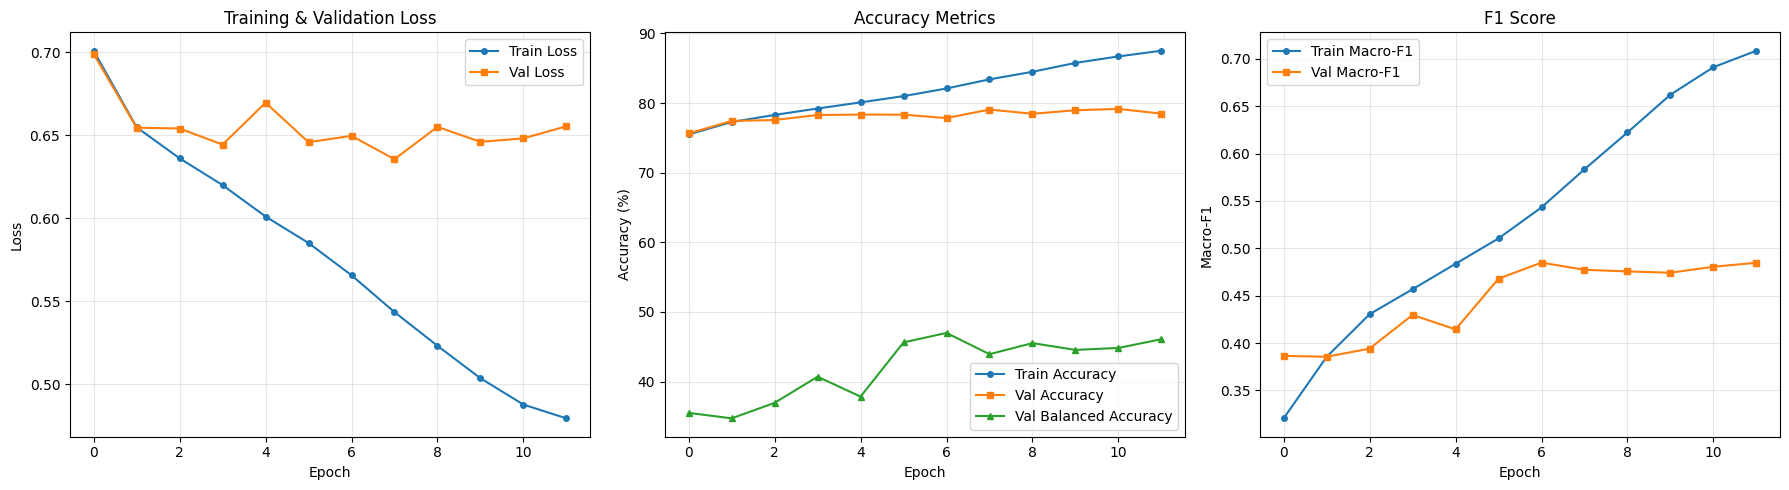

In [19]:
# plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x * 100 for x in history['train_acc']], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot([x * 100 for x in history['val_acc']], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot([x * 100 for x in history['val_bal_acc']], label='Val Balanced Accuracy', marker='^', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train Macro-F1', marker='o', markersize=4)
axes[2].plot(history['val_f1'], label='Val Macro-F1', marker='s', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs/training_curves_distilled_deit.png', dpi=150)
plt.show()

In [ ]:
from collections import Counter
import os

print("Train labels:", Counter(train_dataset.labels))
print("Val labels:  ", Counter(val_dataset.labels))
print("Test labels: ", Counter(test_dataset.labels))

print("\nCheckpoint exists?")
print("Without distillation:", os.path.exists("SplitDATA/checkpoints/best_deit_without_distillation.pth"))
print("With distillation:   ", os.path.exists("SplitDATA/checkpoints/best_distilled_deit_model.pth"))
print("Teacher:             ", os.path.exists("SplitDATA/checkpoints/teacher_regnety160_best.pth"))

Train labels: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Val labels:   Counter({0: 5165, 2: 1050, 1: 495, 3: 178, 4: 138})
Test labels:  Counter({0: 5154, 2: 1058, 1: 493, 3: 172, 4: 149})

Checkpoint exists?
Without distillation: True
With distillation:    True
Teacher:              True


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

os.makedirs("SplitDATA/logs", exist_ok=True)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs


def evaluate_and_save_test_results(
    model,
    test_loader,
    model_name,
    checkpoint_path,
    save_path,
    is_distilled=False
):
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    test_preds = []
    test_labels = []
    test_probs = []

    print(f"\nTesting: {model_name}")

    with torch.no_grad():

        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)
            preds = final_logits.argmax(dim=1)

            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_probs = np.array(test_probs)
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)

    cm = confusion_matrix(test_labels, test_preds)

    test_acc = accuracy_score(test_labels, test_preds)
    test_bal_acc = balanced_accuracy_score(test_labels, test_preds)
    macro_precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_recall = recall_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
    mcc = matthews_corrcoef(test_labels, test_preds)

    try:
        multiclass_auc = roc_auc_score(
            test_labels,
            test_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        multiclass_auc = None

    report = classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    result_text = (
        f"====================================================\n"
        f"TEST RESULTS - {model_name}\n"
        f"====================================================\n\n"
        f"Checkpoint                : {checkpoint_path}\n\n"
        f"Accuracy                  : {test_acc:.4f}\n"
        f"Balanced Accuracy         : {test_bal_acc:.4f}\n"
        f"Macro Precision           : {macro_precision:.4f}\n"
        f"Macro Recall              : {macro_recall:.4f}\n"
        f"Macro F1                  : {macro_f1:.4f}\n"
        f"Weighted F1               : {weighted_f1:.4f}\n"
        f"Quadratic Weighted Kappa  : {qwk:.4f}\n"
        f"Matthews Corrcoef         : {mcc:.4f}\n"
        f"Macro ROC-AUC OvR         : {multiclass_auc if multiclass_auc is not None else 'Not available'}\n\n"
        f"Classification Report:\n"
        f"{report}\n\n"
        f"Confusion Matrix:\n"
        f"{cm}\n\n"
        f"Class-wise Sensitivity / Specificity:\n"
    )

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        result_text += (
            f"{class_name:15s} | "
            f"Sensitivity: {sensitivity:.4f} | "
            f"Specificity: {specificity:.4f}\n"
        )

    print(result_text)

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"\nSaved test results to: {save_path}")

    return {
        "accuracy": test_acc,
        "balanced_accuracy": test_bal_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "qwk": qwk,
        "mcc": mcc,
        "auc": multiclass_auc,
        "cm": cm,
        "preds": test_preds,
        "labels": test_labels,
        "probs": test_probs,
    }

baseline_test_model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=False,
    num_classes=5
).to(device)

baseline_results = evaluate_and_save_test_results(
    model=baseline_test_model,
    test_loader=test_loader,
    model_name="DeiT WITHOUT Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_deit_without_distillation.pth",
    save_path="SplitDATA/logs/test_results_deit_without_distillation.txt",
    is_distilled=False
)


distilled_test_model = timm.create_model(
    "deit_small_distilled_patch16_224",
    pretrained=False,
    num_classes=5,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

distilled_results = evaluate_and_save_test_results(
    model=distilled_test_model,
    test_loader=test_loader,
    model_name="DeiT WITH Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_distilled_deit_model.pth",
    save_path="SplitDATA/logs/test_results_deit_with_distillation.txt",
    is_distilled=True
)
comparison_path = "SplitDATA/logs/test_comparison_summary_argmax.txt"

comparison_text = (
    "====================================================\n"
    "FINAL TEST COMPARISON - ORIGINAL ARGMAX RESULTS\n"
    "====================================================\n\n"
    "1. DeiT WITHOUT Distillation\n"
    f"QWK               : {baseline_results['qwk']:.4f}\n"
    f"Macro F1          : {baseline_results['macro_f1']:.4f}\n"
    f"Accuracy          : {baseline_results['accuracy']:.4f}\n"
    f"Balanced Accuracy : {baseline_results['balanced_accuracy']:.4f}\n\n"
    "2. DeiT WITH Distillation\n"
    f"QWK               : {distilled_results['qwk']:.4f}\n"
    f"Macro F1          : {distilled_results['macro_f1']:.4f}\n"
    f"Accuracy          : {distilled_results['accuracy']:.4f}\n"
    f"Balanced Accuracy : {distilled_results['balanced_accuracy']:.4f}\n\n"
)


print(comparison_text)

with open(comparison_path, "w") as f:
    f.write(comparison_text)

print(f"Saved ARGMAX comparison summary to: {comparison_path}")


/tmp/ipykernel_617293/89613837.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITHOUT Distillation


Testing DeiT WITHOUT Distillation: 100%|██████████| 440/440 [00:12<00:00, 36.39it/s]
/tmp/ipykernel_617293/89613837.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torc

TEST RESULTS - DeiT WITHOUT Distillation

Checkpoint                : SplitDATA/checkpoints/best_deit_without_distillation.pth

Accuracy                  : 0.7690
Balanced Accuracy         : 0.4631
Macro Precision           : 0.5261
Macro Recall              : 0.4631
Macro F1                  : 0.4874
Weighted F1               : 0.7457
Quadratic Weighted Kappa  : 0.6330
Matthews Corrcoef         : 0.4069
Macro ROC-AUC OvR         : 0.7883451655711966

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8379    0.9255    0.8795      5154
         Mild     0.1321    0.0568    0.0794       493
     Moderate     0.5328    0.4376    0.4805      1058
       Severe     0.5039    0.3721    0.4281       172
Proliferative     0.6240    0.5235    0.5693       149

     accuracy                         0.7690      7026
    macro avg     0.5261    0.4631    0.4874      7026
 weighted avg     0.7297    0.7690    0.7457      7026


Confusion Matrix:
[[47

Testing DeiT WITH Distillation: 100%|██████████| 440/440 [00:11<00:00, 36.92it/s]

TEST RESULTS - DeiT WITH Distillation

Checkpoint                : SplitDATA/checkpoints/best_distilled_deit_model.pth

Accuracy                  : 0.7923
Balanced Accuracy         : 0.4672
Macro Precision           : 0.5685
Macro Recall              : 0.4672
Macro F1                  : 0.4979
Weighted F1               : 0.7593
Quadratic Weighted Kappa  : 0.6583
Matthews Corrcoef         : 0.4537
Macro ROC-AUC OvR         : 0.8349571508354255

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8374    0.9525    0.8912      5154
         Mild     0.1757    0.0264    0.0459       493
     Moderate     0.5829    0.4783    0.5254      1058
       Severe     0.5714    0.3488    0.4332       172
Proliferative     0.6752    0.5302    0.5940       149

     accuracy                         0.7923      7026
    macro avg     0.5685    0.4672    0.4979      7026
 weighted avg     0.7427    0.7923    0.7593      7026


Confusion Matrix:
[[4909   46 

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, balanced_accuracy_score
import numpy as np
import torch.nn.functional as F

def apply_thresholds(scores, thresholds):
    thresholds = np.sort(thresholds)

    preds = np.zeros_like(scores, dtype=int)
    preds[scores > thresholds[0]] = 1
    preds[scores > thresholds[1]] = 2
    preds[scores > thresholds[2]] = 3
    preds[scores > thresholds[3]] = 4

    return preds

def qwk_loss(thresholds, scores, labels):
    preds = apply_thresholds(scores, thresholds)
    return -cohen_kappa_score(labels, preds, weights="quadratic")

def get_probs_and_labels(model, loader, is_distilled=False):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Collecting probabilities"):
            images = images.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)

def tune_and_apply_thresholds(model, model_name, is_distilled=False):

    print(f"\nThreshold tuning for: {model_name}")

    val_probs, val_labels = get_probs_and_labels(
        model,
        val_loader,
        is_distilled=is_distilled
    )

    val_scores = val_probs @ np.arange(5)

    result = minimize(
        qwk_loss,
        [0.5, 1.5, 2.5, 3.5],
        args=(val_scores, val_labels),
        method="Nelder-Mead"
    )

    best_thresholds = np.sort(result.x)

    val_preds_tuned = apply_thresholds(val_scores, best_thresholds)

    val_qwk_tuned = cohen_kappa_score(
        val_labels,
        val_preds_tuned,
        weights="quadratic"
    )

    test_probs, test_labels = get_probs_and_labels(
        model,
        test_loader,
        is_distilled=is_distilled
    )

    test_scores = test_probs @ np.arange(5)
    test_preds_tuned = apply_thresholds(test_scores, best_thresholds)

    test_qwk_tuned = cohen_kappa_score(
        test_labels,
        test_preds_tuned,
        weights="quadratic"
    )

    test_f1_tuned = f1_score(
        test_labels,
        test_preds_tuned,
        average="macro",
        zero_division=0
    )

    test_acc_tuned = accuracy_score(test_labels, test_preds_tuned)

    test_bal_acc_tuned = balanced_accuracy_score(
        test_labels,
        test_preds_tuned
    )

    result_text = (
        f"\n====================================================\n"
        f"THRESHOLD TUNING RESULTS - {model_name}\n"
        f"====================================================\n"
        f"Best thresholds        : {best_thresholds}\n"
        f"Tuned Validation QWK   : {val_qwk_tuned:.4f}\n"
        f"Tuned Test QWK         : {test_qwk_tuned:.4f}\n"
        f"Tuned Test Macro F1    : {test_f1_tuned:.4f}\n"
        f"Tuned Test Accuracy    : {test_acc_tuned:.4f}\n"
        f"Tuned Test Bal Accuracy: {test_bal_acc_tuned:.4f}\n"
    )

    print(result_text)

    save_path = f"SplitDATA/logs/threshold_tuning_{model_name.replace(' ', '_').lower()}.txt"

    with open(save_path, "w") as f:
        f.write(result_text)

    return {
        "thresholds": best_thresholds,
        "val_qwk": val_qwk_tuned,
        "test_qwk": test_qwk_tuned,
        "test_macro_f1": test_f1_tuned,
        "test_accuracy": test_acc_tuned,
        "test_balanced_accuracy": test_bal_acc_tuned,
        "test_preds": test_preds_tuned,
        "test_labels": test_labels
    }


baseline_threshold_results = tune_and_apply_thresholds(
    baseline_test_model,
    "DeiT WITHOUT Distillation",
    is_distilled=False
)
distilled_threshold_results = tune_and_apply_thresholds(
    distilled_test_model,
    "DeiT WITH Distillation",
    is_distilled=True
)


Threshold tuning for: DeiT WITHOUT Distillation



THRESHOLD TUNING RESULTS - DeiT WITHOUT Distillation
Best thresholds        : [0.66254253 1.62464165 1.96264845 2.43455031]
Tuned Validation QWK   : 0.6612
Tuned Test QWK         : 0.6796
Tuned Test Macro F1    : 0.3742
Tuned Test Accuracy    : 0.7057
Tuned Test Bal Accuracy: 0.4245


Threshold tuning for: DeiT WITH Distillation



THRESHOLD TUNING RESULTS - DeiT WITH Distillation
Best thresholds        : [0.6081441  1.54561637 1.96097883 2.86299906]
Tuned Validation QWK   : 0.6905
Tuned Test QWK         : 0.6928
Tuned Test Macro F1    : 0.4602
Tuned Test Accuracy    : 0.7276
Tuned Test Bal Accuracy: 0.4677



In [ ]:
import pandas as pd
from IPython.display import display

threshold_comparison_df = pd.DataFrame({
    "Metric": [
        "Tuned Test QWK",
        "Tuned Test Macro F1",
        "Tuned Test Accuracy",
        "Tuned Test Balanced Accuracy"
    ],
    "DeiT WITHOUT Distillation": [
        baseline_threshold_results["test_qwk"],
        baseline_threshold_results["test_macro_f1"],
        baseline_threshold_results["test_accuracy"],
        baseline_threshold_results["test_balanced_accuracy"]
    ],
    "DeiT WITH Distillation": [
        distilled_threshold_results["test_qwk"],
        distilled_threshold_results["test_macro_f1"],
        distilled_threshold_results["test_accuracy"],
        distilled_threshold_results["test_balanced_accuracy"]
    ]
})

threshold_comparison_df.iloc[:, 1:] = threshold_comparison_df.iloc[:, 1:].round(4)

display(
    threshold_comparison_df.style.set_caption(
        "Threshold-Tuned Test Results"
    )
)

threshold_comparison_df.to_csv(
    "SplitDATA/logs/threshold_tuned_comparison_table.csv",
    index=False
)

,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Tuned Test QWK,0.679600,0.692800
1,Tuned Test Macro F1,0.374200,0.460200
2,Tuned Test Accuracy,0.705700,0.727600
3,Tuned Test Balanced Accuracy,0.424500,0.467700


In [ ]:

def analyze_qwk_by_class(predictions, labels, class_names):
    print("\n" + "="*60)
    print("QWK BREAKDOWN BY CLASS")
    print("="*60)
    
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(labels, predictions)
  
    for i, class_name in enumerate(class_names):
        class_mask = labels == i
        class_preds = predictions[class_mask]
        class_labels = labels[class_mask]
        
        if len(class_labels) == 0:
            continue
        
        class_qwk = cohen_kappa_score(class_labels, class_preds, weights="quadratic")
        class_acc = accuracy_score(class_labels, class_preds)
        
        print(f"\n{class_name} (Class {i}):")
        print(f"  Samples: {len(class_labels)}")
        print(f"  Accuracy: {class_acc:.4f}")
        print(f"  QWK: {class_qwk:.4f}")
        print(f"  Confusion: {cm[i]}")

analyze_qwk_by_class(
    distilled_results["preds"],
    distilled_results["labels"],
    class_names
)


QWK BREAKDOWN BY CLASS

No DR (Class 0):
  Samples: 5154
  Accuracy: 0.9525
  QWK: 0.0000
  Confusion: [4909   46  192    2    5]

Mild (Class 1):
  Samples: 493
  Accuracy: 0.0264
  QWK: 0.0000
  Confusion: [430  13  50   0   0]

Moderate (Class 2):
  Samples: 1058
  Accuracy: 0.4783
  QWK: 0.0000
  Confusion: [485  15 506  29  23]

Severe (Class 3):
  Samples: 172
  Accuracy: 0.3488
  QWK: 0.0000
  Confusion: [20  0 82 60 10]

Proliferative (Class 4):
  Samples: 149
  Accuracy: 0.5302
  QWK: 0.0000
  Confusion: [18  0 38 14 79]


In [ ]:
from collections import Counter

print("WITHOUT DISTILLATION")
print("True labels:")
print(Counter(baseline_results["labels"]))

print("\nPredicted labels:")
print(Counter(baseline_results["preds"]))

print("\nWITH DISTILLATION")
print("True labels:")
print(Counter(distilled_results["labels"]))

print("\nPredicted labels:")
print(Counter(distilled_results["preds"]))

WITHOUT DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 5693, np.int64(2): 869, np.int64(1): 212, np.int64(3): 127, np.int64(4): 125})


WITH DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 5862, np.int64(2): 868, np.int64(4): 117, np.int64(3): 105, np.int64(1): 74})


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("SplitDATA/logs/confusion_matrices", exist_ok=True)

def save_confusion_matrix(cm, class_names, title, save_path):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.close()

    print(f"Saved confusion matrix: {save_path}")


save_confusion_matrix(
    baseline_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITHOUT Distillation",
    "SplitDATA/logs/confusion_matrices/cm_without_distillation.png"
)


save_confusion_matrix(
    distilled_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITH Distillation",
    "SplitDATA/logs/confusion_matrices/cm_with_distillation.png"
)

Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_without_distillation.png
Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_with_distillation.png


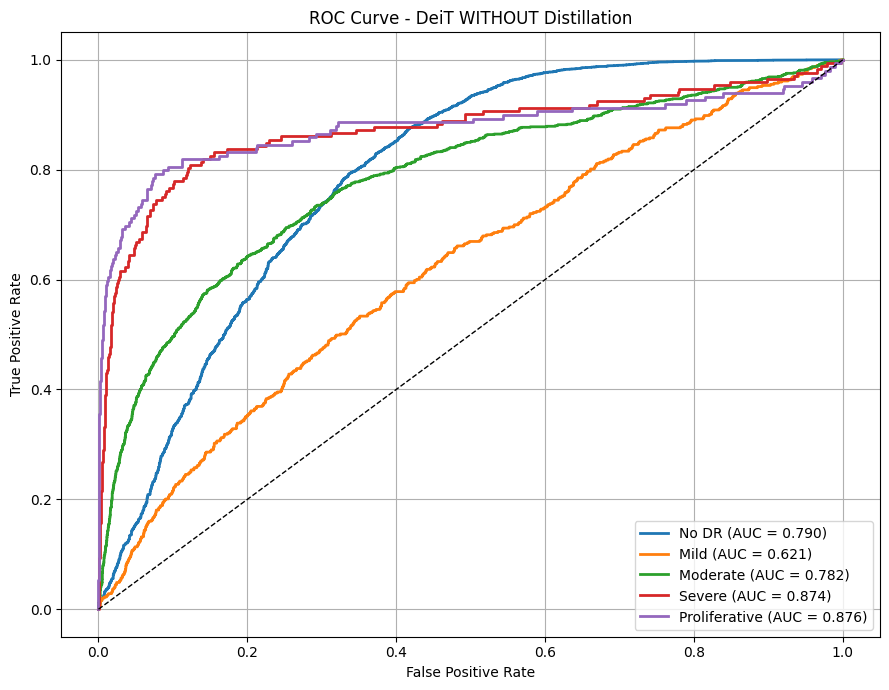

Saved ROC curve: SplitDATA/logs/roc_curves/roc_without_distillation.png


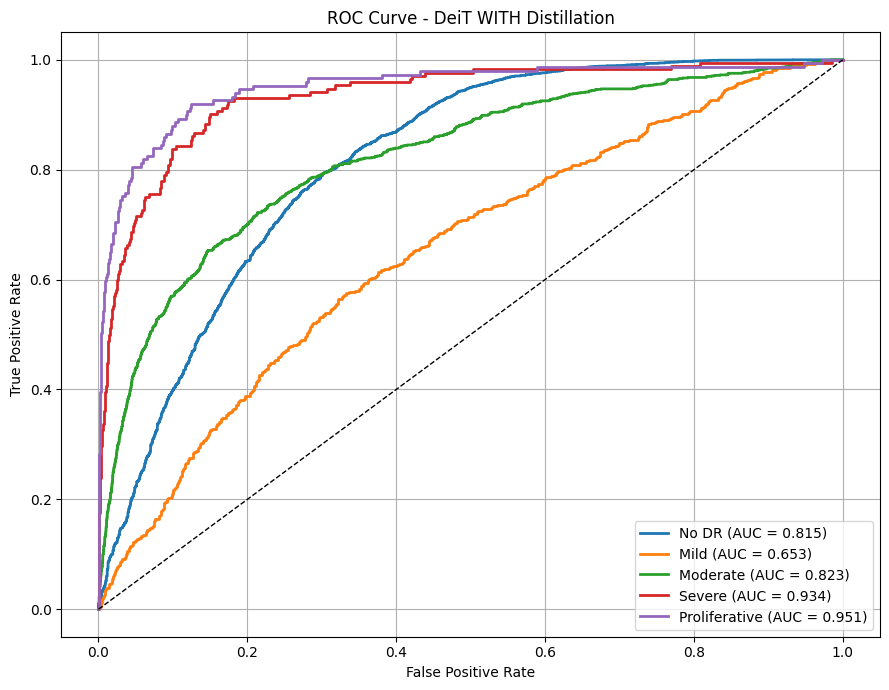

Saved ROC curve: SplitDATA/logs/roc_curves/roc_with_distillation.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

os.makedirs("SplitDATA/logs/roc_curves", exist_ok=True)

def plot_multiclass_roc(
    test_labels,
    test_probs,
    class_names,
    title,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0,1,2,3,4]
    )

    n_classes = y_true_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(9, 7))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
        )

    # random baseline
    plt.plot([0,1], [0,1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.show()

    print(f"Saved ROC curve: {save_path}")


plot_multiclass_roc(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_without_distillation.png"
)



plot_multiclass_roc(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITH Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_with_distillation.png"
)

In [ ]:

from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize
from IPython.display import display
import pandas as pd
import numpy as np
import os

os.makedirs("SplitDATA/logs", exist_ok=True)


def compute_map(
    test_labels,
    test_probs,
    class_names,
    model_name,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0, 1, 2, 3, 4]
    )

    n_classes = y_true_bin.shape[1]

    ap_per_class = []

    result_text = (
        f"====================================================\n"
        f"mAP RESULTS - {model_name}\n"
        f"====================================================\n\n"
    )

    print(f"\n{model_name}")

    for i in range(n_classes):

        ap = average_precision_score(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        ap_per_class.append(ap)

        result_text += f"{class_names[i]} AP: {ap:.4f}\n"

        print(f"{class_names[i]} AP: {ap:.4f}")

    mAP = np.mean(ap_per_class)

    result_text += f"\nmAP: {mAP:.4f}\n"

    print(f"\nmAP: {mAP:.4f}")

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved mAP results to: {save_path}")

    return {
        "ap_per_class": ap_per_class,
        "mAP": mAP
    }



baseline_map_results = compute_map(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    model_name="DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/map_without_distillation.txt"
)



distilled_map_results = compute_map(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    model_name="DeiT WITH Distillation",
    save_path="SplitDATA/logs/map_with_distillation.txt"
)



map_summary_path = "SplitDATA/logs/map_comparison_summary.txt"

summary_text = (
    "====================================================\n"
    "FINAL mAP COMPARISON\n"
    "====================================================\n\n"
    "DeiT WITHOUT Distillation\n"
    f"mAP: {baseline_map_results['mAP']:.4f}\n\n"
    "DeiT WITH Distillation\n"
    f"mAP: {distilled_map_results['mAP']:.4f}\n"
)

print(summary_text)

with open(map_summary_path, "w") as f:
    f.write(summary_text)

print(f"Saved mAP comparison summary to: {map_summary_path}")


comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "QWK",
        "MCC",
        "ROC-AUC OvR",
        "mAP"
    ],

    "DeiT WITHOUT Distillation": [
        baseline_results["accuracy"],
        baseline_results["balanced_accuracy"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"],
        baseline_results["weighted_f1"],
        baseline_results["qwk"],
        baseline_results["mcc"],
        baseline_results["auc"] if baseline_results["auc"] is not None else np.nan,
        baseline_map_results["mAP"]
    ],

    "DeiT WITH Distillation": [
        distilled_results["accuracy"],
        distilled_results["balanced_accuracy"],
        distilled_results["macro_precision"],
        distilled_results["macro_recall"],
        distilled_results["macro_f1"],
        distilled_results["weighted_f1"],
        distilled_results["qwk"],
        distilled_results["mcc"],
        distilled_results["auc"] if distilled_results["auc"] is not None else np.nan,
        distilled_map_results["mAP"]
    ]
    
    
})

comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

print("\nFINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")

display(
    comparison_df.style
    .set_caption("Original Argmax Results: DeiT Without vs With Distillation")
    .set_properties(**{
        "text-align": "center"
    })
)



table_csv_path = "SplitDATA/logs/final_comparison_table_argmax.csv"
table_txt_path = "SplitDATA/logs/final_comparison_table_argmax.txt"

comparison_df.to_csv(table_csv_path, index=False)

with open(table_txt_path, "w") as f:
    f.write("FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")
    f.write("====================================================\n\n")
    f.write(comparison_df.to_string(index=False))

print(f"Saved argmax comparison CSV to: {table_csv_path}")
print(f"Saved argmax comparison TXT to: {table_txt_path}")


DeiT WITHOUT Distillation
No DR AP: 0.8804
Mild AP: 0.1095
Moderate AP: 0.4608
Severe AP: 0.3773
Proliferative AP: 0.5500

mAP: 0.4756
Saved mAP results to: SplitDATA/logs/map_without_distillation.txt

DeiT WITH Distillation
No DR AP: 0.8998
Mild AP: 0.1211
Moderate AP: 0.5180
Severe AP: 0.4506
Proliferative AP: 0.5441

mAP: 0.5067
Saved mAP results to: SplitDATA/logs/map_with_distillation.txt
FINAL mAP COMPARISON

DeiT WITHOUT Distillation
mAP: 0.4756

DeiT WITH Distillation
mAP: 0.5067

Saved mAP comparison summary to: SplitDATA/logs/map_comparison_summary.txt

FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS



,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Accuracy,0.769000,0.792300
1,Balanced Accuracy,0.463100,0.467200
2,Macro Precision,0.526100,0.568500
3,Macro Recall,0.463100,0.467200
4,Macro F1,0.487400,0.497900
5,Weighted F1,0.745700,0.759300
6,QWK,0.633000,0.658300
7,MCC,0.406900,0.453700
8,ROC-AUC OvR,0.788300,0.835000
9,mAP,0.475600,0.506700


Saved argmax comparison CSV to: SplitDATA/logs/final_comparison_table_argmax.csv
Saved argmax comparison TXT to: SplitDATA/logs/final_comparison_table_argmax.txt
